# Requirements

In [1]:
!pip install yfinance

In [2]:
!pip install pandas_datareader

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [4]:
from IPython.display import display, HTML
import builtins
import sys

In [5]:
import pandas_datareader.data as pdr

In [6]:
def make_sequences(scaled_df, seq_length=20):
    X, y = [], []
    arr = scaled_df.values
    t_idx = feature_cols.index(target_col)
    for i in range(len(arr) - seq_length):
        X.append(arr[i:i+seq_length, :])
        y.append(arr[i+seq_length, t_idx])
    return torch.tensor(np.array(X), dtype=torch.float32), torch.tensor(np.array(y), dtype=torch.float32)

In [7]:
def mc_dropout_prediction(model, X, n_iter=100):
    model.train() # Mantener dropout activo para variar las predicciones
    preds = []
    with torch.no_grad():
        for _ in range(n_iter):
            pred = model(X.to(device)).squeeze().cpu().numpy()
            preds.append(pred)
    preds = np.array(preds)
    return preds.mean(axis=0), preds.std(axis=0)


# Enviroment

In [8]:
np.random.seed(1984)
torch.manual_seed(1984)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data Upload

In [95]:
start="2020-01-01"
end="2026-03-27"
country="USA"

In [125]:
# A) Expedia Prices
Empresa="FCX"
px = yf.download(Empresa, start=start, end=end, auto_adjust=False)
if isinstance(px.columns, pd.MultiIndex):
    px.columns = px.columns.get_level_values(0)

px = px.rename(columns={"Adj Close": "AdjClose"})
px = px[["Close", "AdjClose", "Volume"]].dropna()

[*********************100%***********************]  1 of 1 completed


In [126]:
pce_core = pdr.DataReader("PCEPILFE", "fred", start, end)  # Inflation
gdp = pdr.DataReader("GDP", "fred", start, end)           # GDP
ust10y = pdr.DataReader("DGS10", "fred", start, end)      # Bonds 10Y


In [127]:
pce_infl_yoy = pce_core.pct_change(12) * 100
pce_infl_yoy.columns = ["PCE_core_yoy"]

gdp_qoq_saar = ((1 + gdp.pct_change(1)) ** 4 - 1) * 100
gdp_qoq_saar.columns = ["GDP_qoq_saar"]

ust10y.columns = ["UST10Y"]

# Transformations

In [128]:
# Join Macroeconomics, gor each month in the quarter the macroeconomic data will be the data of the end of the period
idx = pd.date_range(start=px.index.min(), end=px.index.max(), freq="B")
df = pd.DataFrame(index=idx)
df = df.join(px[["Close", "Volume"]].reindex(idx).ffill())
df = df.join(pce_infl_yoy.reindex(idx).ffill())
df = df.join(gdp_qoq_saar.reindex(idx).ffill())
df = df.join(ust10y.reindex(idx).ffill()).dropna()

# Model Preparation

In [129]:
# ============================================================
# Variables macroeconómicas por país desde Banco Mundial
# ============================================================

import pandas as pd
import numpy as np
import requests

def descargar_worldbank(country="MEX", start_year=2000, end_year=2026):
    """
    Descarga variables macroeconómicas del Banco Mundial.
    
    country:
        "MEX" para México
        "USA" para Estados Unidos
        "BRA" para Brasil
        etc.
    """

    indicadores = {
        # Deuda pública / PIB nominal x 100
        "deuda_publica_pib": "GC.DOD.TOTL.GD.ZS",

        # IED como porcentaje del PIB
        "ied_pib": "BX.KLT.DINV.WD.GD.ZS",

        # IED en dólares corrientes
        "ied_usd": "BX.KLT.DINV.CD.WD",

        # Permisos de construcción, score Doing Business
        # Nota: generalmente solo llega hasta 2019
        "permisos_construccion": "IC.CNST.PRMT.DFRN.DB1619",

        # Energía renovable como proxy energética
        "energia_renovable_pct": "EG.ELC.RNEW.ZS",
    }

    series = []

    for nombre, codigo in indicadores.items():
        url = (
            f"https://api.worldbank.org/v2/country/{country}/indicator/{codigo}"
            f"?format=json&per_page=20000"
        )

        try:
            r = requests.get(url, timeout=20)
            data_json = r.json()

            if len(data_json) < 2 or data_json[1] is None:
                print(f"No se encontró información para: {nombre}")
                continue

            datos = []
            for obs in data_json[1]:
                year = obs.get("date")
                value = obs.get("value")

                if year is not None and value is not None:
                    datos.append({
                        "date": pd.to_datetime(f"{year}-12-31"),
                        nombre: value
                    })

            temp = pd.DataFrame(datos)

            if temp.empty:
                print(f"Serie vacía: {nombre}")
                continue

            temp = temp.set_index("date").sort_index()
            temp = temp.loc[
                (temp.index.year >= start_year) &
                (temp.index.year <= end_year)
            ]

            series.append(temp)

        except Exception as e:
            print(f"No se pudo descargar {nombre}: {e}")

    if len(series) == 0:
        return pd.DataFrame()

    macro = pd.concat(series, axis=1).sort_index()

    return macro


macro_anual = descargar_worldbank(
    country=country,
    start_year=2020,
    end_year=2026
)

display(macro_anual)

,deuda_publica_pib,ied_pib,ied_usd,permisos_construccion,energia_renovable_pct
date,,,,,
2020-12-31,126.370406,0.650821,137066000000,NaN,19.916699
2021-12-31,120.367733,2.049986,477956000000,NaN,20.273309
2022-12-31,114.694842,1.628168,416890000000,NaN,NaN
2023-12-31,116.918809,1.326183,361944000000,NaN,NaN
2024-12-31,117.973235,1.033211,297058000000,NaN,NaN


In [130]:
# ============================================================
# Pasar variables macro anuales a frecuencia diaria
# ============================================================

macro_diario = macro_anual.resample("D").ffill()

# Asegurar que el índice de df sea datetime
df.index = pd.to_datetime(df.index)

# Unir con la base financiera
df = df.join(macro_diario, how="left")

# Rellenar hacia adelante
df = df.ffill()

display(df.tail())

,Close,Volume,PCE_core_yoy,GDP_qoq_saar,UST10Y,deuda_publica_pib,ied_pib,ied_usd,permisos_construccion,energia_renovable_pct
2026-03-20,52.090000,25007300.0,3.05088,4.239671,4.39,117.973235,1.033211,2.970580e+11,NaN,20.273309
2026-03-23,54.939999,24888600.0,3.05088,4.239671,4.34,117.973235,1.033211,2.970580e+11,NaN,20.273309
2026-03-24,56.480000,17123000.0,3.05088,4.239671,4.39,117.973235,1.033211,2.970580e+11,NaN,20.273309
2026-03-25,57.090000,13965000.0,3.05088,4.239671,4.33,117.973235,1.033211,2.970580e+11,NaN,20.273309
2026-03-26,55.830002,16016500.0,3.05088,4.239671,4.42,117.973235,1.033211,2.970580e+11,NaN,20.273309


In [131]:
# ============================================================
# Nuevas variables explicativas
# ============================================================

target_col = "Close"

feature_cols = [
    "Close",
    "Volume",
    "PCE_core_yoy",
    "GDP_qoq_saar",
    "UST10Y",

    # Variables nuevas
    "deuda_publica_pib",
    "ied_pib",
    "ied_usd",
    "permisos_construccion",
    "energia_renovable_pct"
]

# Nos quedamos solo con columnas que realmente existan
feature_cols = [col for col in feature_cols if col in df.columns]

print("Variables encontradas:")
print(feature_cols)

# Diagnóstico de faltantes
print("\nNaN por variable antes de limpiar:")
print(df[feature_cols].isna().sum())

# Quitamos columnas completamente vacías
feature_cols = [
    col for col in feature_cols
    if not df[col].isna().all()
]

# Opcional: quitar columnas con demasiados NaN
limite_na = 0.80

feature_cols_limpias = []

for col in feature_cols:
    prop_na = df[col].isna().mean()
    
    if prop_na <= limite_na:
        feature_cols_limpias.append(col)
    else:
        print(f"Se elimina {col} por demasiados NaN: {prop_na:.2%}")

feature_cols = feature_cols_limpias

# Rellenamos faltantes
df[feature_cols] = df[feature_cols].ffill().bfill()

# Ahora sí creamos data
data = df[feature_cols].dropna(subset=[target_col]).copy()

print("\nVariables usadas finales:")
print(feature_cols)

print("\nTamaño final de data:", data.shape)
display(data.head())
display(data.tail())

Variables encontradas:
['Close', 'Volume', 'PCE_core_yoy', 'GDP_qoq_saar', 'UST10Y', 'deuda_publica_pib', 'ied_pib', 'ied_usd', 'permisos_construccion', 'energia_renovable_pct']

NaN por variable antes de limpiar:
Close                       0
Volume                      0
PCE_core_yoy                0
GDP_qoq_saar                0
UST10Y                      0
deuda_publica_pib           0
ied_pib                     0
ied_usd                     0
permisos_construccion    1365
energia_renovable_pct       0
dtype: int64

Variables usadas finales:
['Close', 'Volume', 'PCE_core_yoy', 'GDP_qoq_saar', 'UST10Y', 'deuda_publica_pib', 'ied_pib', 'ied_usd', 'energia_renovable_pct']

Tamaño final de data: (1365, 9)


,Close,Volume,PCE_core_yoy,GDP_qoq_saar,UST10Y,deuda_publica_pib,ied_pib,ied_usd,energia_renovable_pct
2021-01-01,26.020000,16527900.0,1.697494,11.190011,0.93,126.370406,0.650821,1.370660e+11,19.916699
2021-01-04,27.139999,31398600.0,1.697494,11.190011,0.93,126.370406,0.650821,1.370660e+11,19.916699
2021-01-05,28.370001,26109100.0,1.697494,11.190011,0.96,126.370406,0.650821,1.370660e+11,19.916699
2021-01-06,30.160000,40670400.0,1.697494,11.190011,1.04,126.370406,0.650821,1.370660e+11,19.916699
2021-01-07,31.170000,29770900.0,1.697494,11.190011,1.08,126.370406,0.650821,1.370660e+11,19.916699


,Close,Volume,PCE_core_yoy,GDP_qoq_saar,UST10Y,deuda_publica_pib,ied_pib,ied_usd,energia_renovable_pct
2026-03-20,52.090000,25007300.0,3.05088,4.239671,4.39,117.973235,1.033211,2.970580e+11,20.273309
2026-03-23,54.939999,24888600.0,3.05088,4.239671,4.34,117.973235,1.033211,2.970580e+11,20.273309
2026-03-24,56.480000,17123000.0,3.05088,4.239671,4.39,117.973235,1.033211,2.970580e+11,20.273309
2026-03-25,57.090000,13965000.0,3.05088,4.239671,4.33,117.973235,1.033211,2.970580e+11,20.273309
2026-03-26,55.830002,16016500.0,3.05088,4.239671,4.42,117.973235,1.033211,2.970580e+11,20.273309


In [132]:
def calcular_psi(expected, actual, bins=10, eps=1e-6):
    """
    Calcula el Population Stability Index entre dos distribuciones.
    
    expected: periodo base o referencia
    actual: periodo que se quiere comparar
    bins: número de grupos para discretizar la variable continua
    """
    
    expected = pd.Series(expected).dropna()
    actual = pd.Series(actual).dropna()
    
    # Cortes por cuantiles usando la distribución de referencia
    cortes = np.quantile(expected, np.linspace(0, 1, bins + 1))
    cortes = np.unique(cortes)
    
    # Si hay pocos valores distintos, no se puede calcular bien el PSI
    if len(cortes) <= 2:
        return np.nan
    
    expected_bins = pd.cut(expected, bins=cortes, include_lowest=True)
    actual_bins = pd.cut(actual, bins=cortes, include_lowest=True)
    
    expected_dist = expected_bins.value_counts(normalize=True).sort_index()
    actual_dist = actual_bins.value_counts(normalize=True).sort_index()
    
    # Alinear categorías
    actual_dist = actual_dist.reindex(expected_dist.index, fill_value=0)
    
    # Evitar log(0)
    expected_dist = expected_dist.replace(0, eps)
    actual_dist = actual_dist.replace(0, eps)
    
    psi = np.sum((actual_dist - expected_dist) * np.log(actual_dist / expected_dist))
    
    return psi

In [133]:
# ============================================================
# PSI anual de la variable objetivo
# ============================================================

umbral_psi = 0.10

data_psi = data.copy()
data_psi["year"] = data_psi.index.year

anio_referencia = data_psi["year"].max()

base_referencia = data_psi.loc[
    data_psi["year"] == anio_referencia, 
    target_col
]

resultados_psi = []

for anio in sorted(data_psi["year"].unique()):
    if anio == anio_referencia:
        continue
    
    muestra_anio = data_psi.loc[
        data_psi["year"] == anio, 
        target_col
    ]
    
    psi = calcular_psi(
        expected=base_referencia,
        actual=muestra_anio,
        bins=10
    )
    
    resultados_psi.append({
        "anio": anio,
        "variable": target_col,
        "psi": psi,
        "usar_anio": psi < umbral_psi
    })

psi_anual = pd.DataFrame(resultados_psi)

print("Año de referencia:", anio_referencia)
display(psi_anual)

Año de referencia: 2026


,anio,variable,psi,usar_anio
0,2021,Close,0.000000,True
1,2022,Close,12.096304,False
2,2023,Close,0.000000,True
3,2024,Close,12.096304,False
4,2025,Close,12.096304,False


In [134]:
# ============================================================
# Filtrar horizonte temporal usando PSI < 10%
# ============================================================

anios_validos = psi_anual.loc[
    psi_anual["usar_anio"], 
    "anio"
].tolist()

# Incluimos también el año de referencia
anios_validos.append(anio_referencia)

print("Años seleccionados por PSI:", anios_validos)

data_filtrada = data.loc[
    data.index.year.isin(anios_validos)
].copy()

print("Tamaño original:", data.shape)
print("Tamaño filtrado:", data_filtrada.shape)

Años seleccionados por PSI: [2021, 2023, 2026]
Tamaño original: (1365, 9)
Tamaño filtrado: (582, 9)


In [135]:
# ============================================================
# Train/Test usando solo el horizonte válido por PSI
# ============================================================

train_size = int(len(data_filtrada) * 0.8)

train_df = data_filtrada.iloc[:train_size]
test_df = data_filtrada.iloc[train_size:]

print("Train:", train_df.index.min(), "a", train_df.index.max())
print("Test:", test_df.index.min(), "a", test_df.index.max())

Train: 2021-01-01 00:00:00 a 2023-10-12 00:00:00
Test: 2023-10-13 00:00:00 a 2026-03-26 00:00:00


In [136]:
# Normalization Min-Max
mins, maxs = train_df.min(), train_df.max()
ranges = (maxs - mins).replace(0, 1e-9)

In [137]:
train_scaled = (train_df - mins) / ranges
test_scaled = (test_df - mins) / ranges
t_min, t_max = mins[target_col], maxs[target_col]

In [138]:
X_train, y_train = make_sequences(train_scaled)
X_test, y_test = make_sequences(test_scaled)

# Model Definition

In [139]:
class EXPELSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, num_layers=1, dropout=0.2):
        super(EXPELSTM, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :] # Tomamos solo el último estado de la secuencia
        out = self.dropout(out)
        return self.fc(out)

In [140]:
model = EXPELSTM(input_dim=len(feature_cols)).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

# Model Training

In [141]:
epochs = 3000

model.train()

for epoch in range(1, epochs + 1):
    optimizer.zero_grad()
    
    preds = model(X_train.to(device))              # [28, 1]
    target = y_train.to(device).view(-1, 1)        # [28, 1]
    
    loss = criterion(preds, target)
    
    loss.backward()
    optimizer.step()
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch} - Loss: {loss.item():.6f}")

Epoch 10 - Loss: 0.290446
Epoch 20 - Loss: 0.098677
Epoch 30 - Loss: 0.035048
Epoch 40 - Loss: 0.026439
Epoch 50 - Loss: 0.024474
Epoch 60 - Loss: 0.023833
Epoch 70 - Loss: 0.022339
Epoch 80 - Loss: 0.024146
Epoch 90 - Loss: 0.023921
Epoch 100 - Loss: 0.020903
Epoch 110 - Loss: 0.021767
Epoch 120 - Loss: 0.019257
Epoch 130 - Loss: 0.022236
Epoch 140 - Loss: 0.020858
Epoch 150 - Loss: 0.019481
Epoch 160 - Loss: 0.017794
Epoch 170 - Loss: 0.017995
Epoch 180 - Loss: 0.016713
Epoch 190 - Loss: 0.018795
Epoch 200 - Loss: 0.015133
Epoch 210 - Loss: 0.016444
Epoch 220 - Loss: 0.014142
Epoch 230 - Loss: 0.013924
Epoch 240 - Loss: 0.014132
Epoch 250 - Loss: 0.011730
Epoch 260 - Loss: 0.013449
Epoch 270 - Loss: 0.012392
Epoch 280 - Loss: 0.011467
Epoch 290 - Loss: 0.011838
Epoch 300 - Loss: 0.011643
Epoch 310 - Loss: 0.011040
Epoch 320 - Loss: 0.010592
Epoch 330 - Loss: 0.010005
Epoch 340 - Loss: 0.009793
Epoch 350 - Loss: 0.010200
Epoch 360 - Loss: 0.009869
Epoch 370 - Loss: 0.009995
Epoch 380 

In [142]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

with torch.no_grad():
    salida = model(X_train.to(device))
    print("Salida del modelo:", salida.shape)

X_train: torch.Size([445, 20, 9])
y_train: torch.Size([445])
Salida del modelo: torch.Size([445, 1])


# Uncertainty with MC-Drop Out

In [143]:
mean_preds_scaled, std_preds_scaled = mc_dropout_prediction(model, X_test)

In [144]:
# USD Scaling 
mean_preds_usd = mean_preds_scaled * (t_max - t_min) + t_min
upper_bound = (mean_preds_scaled + 1.96 * std_preds_scaled) * (t_max - t_min) + t_min
lower_bound = (mean_preds_scaled - 1.96 * std_preds_scaled) * (t_max - t_min) + t_min
y_test_usd = y_test.numpy() * (t_max - t_min) + t_min

# Visualization

In [145]:
# 1. Obtenemos la longitud real de tus predicciones
n_predicciones = len(y_test_usd)

# 2. Ajustamos el índice tomando los ÚLTIMOS 'n' elementos del dataframe original
# Esto garantiza que si tienes 354 precios, tengas las últimas 354 fechas.
test_index_ajustado = test_df.index[-n_predicciones:]

# 3. Verificamos en consola (esto es para tu tranquilidad)
print(f"Longitud del índice: {len(test_index_ajustado)}")
print(f"Longitud de los precios: {len(y_test_usd)}")




Longitud del índice: 97
Longitud de los precios: 97


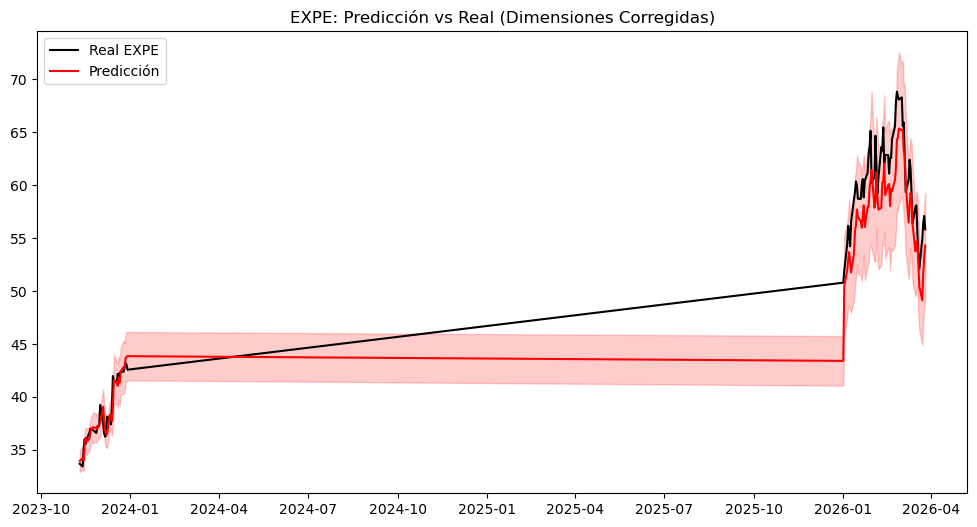

In [146]:
plt.figure(figsize=(12, 6))
plt.plot(test_index_ajustado, y_test_usd, label="Real EXPE", color="black")
plt.plot(test_index_ajustado, mean_preds_usd, label="Predicción", color="red")
plt.fill_between(test_index_ajustado, lower_bound, upper_bound, color="red", alpha=0.2)
plt.title("EXPE: Predicción vs Real (Dimensiones Corregidas)")
plt.legend()
plt.show()

In [147]:
import os
# Rango solicitado
fecha_inicio = "2026-03-30"
fecha_fin = "2026-04-04"

# Como EXPE cotiza en días hábiles, generamos solo días bursátiles
future_dates = pd.date_range(start=fecha_inicio, end=fecha_fin, freq="B")

# Longitud de secuencia usada en tu modelo
seq_length = 20

# Última ventana observada
rolling_window = data[feature_cols].iloc[-seq_length:].copy()

# Últimos valores conocidos de variables exógenas
last_volume = data["Volume"].iloc[-1]
last_pce = data["PCE_core_yoy"].iloc[-1]
last_gdp = data["GDP_qoq_saar"].iloc[-1]
last_ust10y = data["UST10Y"].iloc[-1]

future_preds = []

model.eval()

for fecha in future_dates:
    # Escalamos la ventana móvil con los mismos parámetros de entrenamiento
    rolling_scaled = (rolling_window[feature_cols] - mins[feature_cols]) / ranges[feature_cols]

    # Tensor para el modelo: (1, seq_length, n_features)
    X_future = torch.tensor(
        rolling_scaled.values[np.newaxis, :, :],
        dtype=torch.float32
    ).to(device)

    with torch.no_grad():
        pred_scaled = model(X_future).item()

    # Regresar a escala original
    pred_close = pred_scaled * (t_max - t_min) + t_min
    future_preds.append(pred_close)

    # Nueva fila proyectada
    nueva_fila = pd.DataFrame({
        "Close": [pred_close],
        "Volume": [last_volume],
        "PCE_core_yoy": [last_pce],
        "GDP_qoq_saar": [last_gdp],
        "UST10Y": [last_ust10y]
    }, index=[fecha])

    # Actualizamos la ventana
    rolling_window = pd.concat([rolling_window.iloc[1:], nueva_fila])

# DataFrame final
predicciones_futuras = pd.DataFrame({
    "Fecha": future_dates,
    f"{Empresa}_Prediccion": np.round(future_preds, 4)
})


# Ruta de salida
carpeta_salida = r"C:\Users\molvr\OneDrive\Desktop\proyecto_millonario"
os.makedirs(carpeta_salida, exist_ok=True)

archivo_excel = os.path.join(carpeta_salida, f"{Empresa}_prediccion.xlsx")
# Exportar a Excel
predicciones_futuras.to_excel(archivo_excel, index=False)

print("Archivo guardado en:")
print(archivo_excel)
display(predicciones_futuras)

Archivo guardado en:
C:\Users\molvr\OneDrive\Desktop\proyecto_millonario\FCX_prediccion.xlsx


,Fecha,FCX_Prediccion
0,2026-03-30,53.0966
1,2026-03-31,NaN
2,2026-04-01,NaN
3,2026-04-02,NaN
4,2026-04-03,NaN
